# Preliminary EXIOBASE disaggregation test

**Purpose:** Demonstrate technical feasibility of splitting Sweden into "Stockholm" and "Rest of Sweden" within EXIOBASE 3, then computing production-based and consumption-based accounts for both sub-regions.

This notebook uses **proxy weights** (population share, rough sector estimates) rather than the full Anthesis data collection. It is a proof-of-concept for the April 27 workshop, not a final analysis.

**EXIOBASE version:** 3.10.1 (pxp, year 2024), published Mar 23, 2026.

**System size:** 200 products × 49 regions = 9,800. After splitting Sweden: 200 products × 50 regions = 10,000.

In [1]:
import pymrio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import logging
import time

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

## Configuration

In [2]:
# Path to EXIOBASE 3 zip file (adjust to your local setup).
EXIOBASE_PATH = Path("C:/EXIOBASE3/IOT_2024_pxp.zip")
if not EXIOBASE_PATH.exists():
    raise FileNotFoundError(f"EXIOBASE file not found: {EXIOBASE_PATH}")

# Output directory for results.
OUTPUT_DIR = Path("./results_stockholm_test")
OUTPUT_DIR.mkdir(exist_ok=True)

# Sweden's country code in EXIOBASE.
SWEDEN_CODE = "SE"

# New region codes for the split.
STOCKHOLM_CODE = "SE_STHLM"
REST_OF_SWEDEN_CODE = "SE_REST"

# Stockholm's approximate share of Swedish final demand
# (income-weighted population share: ~24% of population but higher income).
DEMAND_WEIGHT_STHLM = 0.28

# Base year.
BASE_YEAR = 2024

## Step 1: Define proxy weights for Stockholm

For the full analysis, these weights come from Dun & Bradstreet / SCB data on sector-level input goods in Stockholm vs. Sweden. For this test, we use rough proxies based on Stockholm's known economic profile.

In [3]:
def build_proxy_weights():
    """
    Build proxy sector weights for Stockholm.

    Each weight represents Stockholm's share of a sector's national output.
    They do NOT sum to 1 across sectors. Each is independent:
    "Stockholm accounts for X% of this sector nationally."
    """
    default_weight = 0.24

    overrides = {
        # Stockholm has relatively MORE of these (above population share):
        "financial": 0.45,
        "insurance": 0.40,
        "real estate": 0.35,
        "computer": 0.40,
        "telecommunication": 0.35,
        "publishing": 0.35,
        "research": 0.35,
        "other business": 0.30,
        "public admin": 0.25,
        "education": 0.25,
        "health": 0.25,
        "construction": 0.30,
        "hotel": 0.28,
        "restaurant": 0.28,
        "wholesale": 0.30,
        "retail": 0.28,
        "air transport": 0.40,

        # Stockholm has relatively LESS of these (below population share):
        "mining": 0.02,
        "quarrying": 0.05,
        "forestry": 0.02,
        "logging": 0.02,
        "fishing": 0.03,
        "agriculture": 0.05,
        "cultivation": 0.05,
        "crop": 0.05,
        "cattle": 0.03,
        "pulp": 0.01,
        "paper": 0.03,
        "wood": 0.05,
        "basic iron": 0.01,
        "basic precious": 0.01,
        "basic non-ferrous": 0.02,
        "electricity": 0.15,
        "steam": 0.20,
    }

    return default_weight, overrides


def assign_weights(sectors, default_weight, overrides):
    """Assign a Stockholm share weight to each EXIOBASE sector via substring matching."""
    weights = {}
    for sector in sectors:
        sector_lower = sector.lower()
        matched = False
        for substring, weight in overrides.items():
            if substring in sector_lower:
                weights[sector] = weight
                matched = True
                break
        if not matched:
            weights[sector] = default_weight
    return weights

## Step 2: Load EXIOBASE

pymrio parses the raw transaction matrix (Z) and final demand (Y) but does not pre-compute the technical coefficient matrix (A). We call `calc_system()` to derive A and the Leontief inverse L.

In [4]:
def load_exiobase(path):
    """Load EXIOBASE 3, compute A and L, and verify satellite extensions."""
    log.info(f"Loading EXIOBASE from {path} ...")
    t0 = time.time()

    exio = pymrio.parse_exiobase3(path=path)

    log.info(f"Parsed in {time.time() - t0:.1f}s. Computing A matrix ...")
    exio.calc_system()

    log.info(f"A matrix shape: {exio.A.shape}")
    log.info(f"Y matrix shape: {exio.Y.shape}")
    log.info(f"Regions: {exio.get_regions().tolist()[:5]} ... "
             f"({len(exio.get_regions())} total)")
    log.info(f"Sectors per region: {len(exio.get_sectors())}")

    # Log available extensions.
    for ext_name in ['material', 'air_emissions', 'factor_inputs']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            log.info(f"Extension '{ext_name}': {ext.F.shape[0]} stressors")
        else:
            log.warning(f"Extension '{ext_name}': NOT FOUND")

    return exio

In [5]:
exio = load_exiobase(EXIOBASE_PATH)

2026-04-14 17:56:34,902 INFO Loading EXIOBASE from C:\EXIOBASE3\IOT_2024_pxp.zip ...
2026-04-14 17:56:34,925 INFO Read metadata from C:\EXIOBASE3\IOT_2024_pxp.zip
2026-04-14 17:56:34,928 INFO 20260414 17:56:34 - FILEIO -  Loaded IO system from C:\EXIOBASE3\IOT_2024_pxp.zip - 
2026-04-14 17:56:34,930 INFO Load data from Z.txt
2026-04-14 17:56:56,619 INFO Load data from Y.txt
2026-04-14 17:56:56,861 INFO Load data from x.txt
2026-04-14 17:56:56,877 INFO Load data from unit.txt
2026-04-14 17:56:56,907 INFO Load data from land/F.txt
2026-04-14 17:56:57,031 INFO Load data from land/F_Y.txt
2026-04-14 17:56:57,043 INFO Load data from land/unit.txt
2026-04-14 17:56:57,048 INFO 20260414 17:56:57 - FILEIO -  Added satellite account from land
2026-04-14 17:56:57,056 INFO Load data from nutrients/F.txt
2026-04-14 17:56:57,194 INFO Load data from nutrients/F_Y.txt
2026-04-14 17:56:57,203 INFO Load data from nutrients/unit.txt
2026-04-14 17:56:57,207 INFO 20260414 17:56:57 - FILEIO -  Added satelli

## Material and GHG category mappings

Map the 62 EXIOBASE material extraction rows to the four Anthesis primary categories (biomass, fossil, metals, minerals). Also define GHG aggregation with GWP-100 conversion.

In [6]:
# =============================================================================
# Material rows -> Anthesis four primary categories
# =============================================================================

MATERIAL_CATEGORY_MAP = {
    # BIOMASS (rows 0-22): all crops, forestry, fishery
    "biomass": list(range(0, 23)),
    # FOSSIL (rows 23-32): all fossil fuels
    "fossil": list(range(23, 33)),
    # METALS (rows 33-47): all metal ores
    "metals": list(range(33, 48)),
    # MINERALS (rows 48-61): all non-metallic minerals
    "minerals": list(range(48, 62)),
    # RECYCLED: no direct equivalent in EXIOBASE extraction satellites.
    "recycled": [],
}


def aggregate_material_categories(F_material):
    """
    Aggregate the 62 EXIOBASE material extraction rows
    into the four Anthesis primary categories.

    Works on any DataFrame with the same 62-row index:
    F matrices, D_cba, D_pba, or single-region slices.
    """
    row_names = F_material.index.tolist()
    result = {}
    for category, row_indices in MATERIAL_CATEGORY_MAP.items():
        if not row_indices:
            continue
        selected_rows = [row_names[i] for i in row_indices]
        result[category] = F_material.loc[selected_rows].sum(axis=0)
    return pd.DataFrame(result).T


# Verify mapping covers all 62 rows with no overlaps.
all_indices = []
for cat, indices in MATERIAL_CATEGORY_MAP.items():
    all_indices.extend(indices)
assert sorted(all_indices) == list(range(62)), "Mapping does not cover all 62 rows!"
assert len(all_indices) == len(set(all_indices)), "Overlapping indices!"
print("Material category mapping OK: 62 rows -> 4 categories")


# =============================================================================
# GHG emission rows -> aggregated GHG (CO2e)
#
# Unit fix (v3): confirmed from EXIOBASE 3 unit.txt:
#   SF6 - air : kg          -> multiply by GWP 23,500
#   HFC - air : kg CO2-eq   -> GWP = 1 (already CO2e)
#   PFC - air : kg CO2-eq   -> GWP = 1 (already CO2e)
#
# All outputs divided by 1e6 to convert kg CO2e -> kt CO2e,
# consistent with the materials satellite (kt).
# =============================================================================

GWP = {
    "CO2": 1,
    "CH4": 28,
    "N2O": 265,
    "SF6": 23500,   # physical kg  (confirmed in EXIOBASE 3 unit.txt)
    "HFC": 1,       # already kg CO2-eq (confirmed in EXIOBASE 3 unit.txt)
    "PFC": 1,       # already kg CO2-eq (confirmed in EXIOBASE 3 unit.txt)
}

# Rows included in FOSSIL GHG total (excluding biogenic).
GHG_FOSSIL_ROWS = {
    "CO2": [
        "CO2 - combustion - air",
        "CO2 - non combustion - Cement production - air",
        "CO2 - non combustion - Lime production - air",
        "CO2 - waste - fossil - air",
    ],
    "CH4": [
        "CH4 - combustion - air",
        "CH4 - non combustion - Extraction/production of (natural) gas - air",
        "CH4 - non combustion - Extraction/production of crude oil - air",
        "CH4 - non combustion - Mining of antracite - air",
        "CH4 - non combustion - Mining of bituminous coal - air",
        "CH4 - non combustion - Mining of coking coal - air",
        "CH4 - non combustion - Mining of lignite (brown coal) - air",
        "CH4 - non combustion - Mining of sub-bituminous coal - air",
        "CH4 - non combustion - Oil refinery - air",
        "CH4 - agriculture - air",
        "CH4 - waste - air",
    ],
    "N2O": [
        "N2O - combustion - air",
        "N2O - agriculture - air",
    ],
    "SF6": ["SF6 - air"],
    "HFC": ["HFC - air"],
    "PFC": ["PFC - air"],
}

GHG_BIOGENIC_ROWS = [
    "CO2_bio - combustion - air",
    "CH4_bio - combustion - air",
    "N2O_bio - combustion - air",
    "CO2 - agriculture - peat decay - air",
    "CO2 - waste - biogenic - air",
]


def aggregate_ghg(F_air):
    """
    Aggregate air emission rows into fossil GHG (CO2e) and biogenic CO2e.

    Source unit : kg  (EXIOBASE 3 air_emissions satellite).
    Output unit : kt CO2e (divided by 1e6 before returning).

    SF6 rows are multiplied by GWP = 23,500 (physical kg, per unit.txt).
    HFC and PFC rows use GWP = 1 (already stored as kg CO2-eq, per unit.txt).
    CO2, CH4, N2O rows are physical kg, multiplied by AR5 GWP-100.

    Works on any DataFrame whose index is the 420-row air_emissions index.
    """
    all_rows = F_air.index.tolist()

    fossil_total = pd.Series(0.0, index=F_air.columns)
    for gas, rows in GHG_FOSSIL_ROWS.items():
        gwp = GWP[gas]
        for row_name in rows:
            if row_name in all_rows:
                fossil_total += F_air.loc[row_name] * gwp
            else:
                print(f"  WARNING: '{row_name}' not found in air_emissions index")

    bio_total = pd.Series(0.0, index=F_air.columns)
    for row_name in GHG_BIOGENIC_ROWS:
        if row_name in all_rows:
            if "CO2" in row_name:
                bio_total += F_air.loc[row_name] * 1
            elif "CH4" in row_name:
                bio_total += F_air.loc[row_name] * 28
            elif "N2O" in row_name:
                bio_total += F_air.loc[row_name] * 265

    # Convert kg CO2e -> kt CO2e
    fossil_total = fossil_total / 1e6
    bio_total    = bio_total    / 1e6

    return pd.DataFrame({
        "GHG_fossil_CO2e_kt":   fossil_total,
        "GHG_biogenic_CO2e_kt": bio_total,
    }).T


# Verify all specified GHG rows exist.
air_rows = exio.air_emissions.F.index.tolist()
missing = []
for gas, rows in GHG_FOSSIL_ROWS.items():
    for r in rows:
        if r not in air_rows:
            missing.append(r)
for r in GHG_BIOGENIC_ROWS:
    if r not in air_rows:
        missing.append(r)

if missing:
    print(f"WARNING: {len(missing)} row(s) not found:")
    for m in missing:
        print(f"  {m}")
else:
    print("GHG row mapping OK: all specified rows found")


Material category mapping OK: 62 rows -> 4 categories
GHG row mapping OK: all specified rows found


## Sanity check: Sweden totals before disaggregation

Compare against known benchmarks:
- Sweden's total domestic material extraction: roughly 200-300 Mt/year
- Sweden's territorial GHG emissions: roughly 45-50 Mt CO2e/year

In [7]:
# Material extraction totals for Sweden.
mat_F_se = exio.material.F.loc[:, SWEDEN_CODE]
mat_agg = aggregate_material_categories(mat_F_se)
print("Sweden total material extraction (by Anthesis category):")
for cat in mat_agg.index:
    total = mat_agg.loc[cat].sum()
    print(f"  {cat:12s}: {total:>15,.2f}  (check unit)")

print()

# GHG emission totals for Sweden.
air_F_se = exio.air_emissions.F.loc[:, SWEDEN_CODE]
ghg_agg = aggregate_ghg(air_F_se)
print("Sweden total GHG emissions:")
for row in ghg_agg.index:
    total = ghg_agg.loc[row].sum()
    print(f"  {row}: {total:>15,.2f}  (check unit)")

print()
print("NOTE: EXIOBASE material units are typically kt (kilotonnes).")
print("EXIOBASE emission units are typically kt of the gas (before GWP conversion).")
print("After GWP conversion above, the GHG total is in kt CO2e.")

Sweden total material extraction (by Anthesis category):
  biomass     :       64,371.56  (check unit)
  fossil      :          200.94  (check unit)
  metals      :       85,279.54  (check unit)
  minerals    :      128,672.72  (check unit)

Sweden total GHG emissions:
  GHG_fossil_CO2e_kt:       24,993.34  (check unit)
  GHG_biogenic_CO2e_kt:          427.94  (check unit)

NOTE: EXIOBASE material units are typically kt (kilotonnes).
EXIOBASE emission units are typically kt of the gas (before GWP conversion).
After GWP conversion above, the GHG total is in kt CO2e.


## Step 3: Disaggregate Sweden into Stockholm + Rest of Sweden

**Disaggregation logic:**
- A-matrix **columns** (input recipes) are **copied** to both sub-regions. The assumption is that Stockholm's and rest-of-Sweden's sectors buy the same mix of inputs per unit of output.
- A-matrix **rows** (supply allocation) are **split by alpha**. When any sector buys from "Swedish sector i", that purchase is allocated between Stockholm and rest-of-Sweden proportionally to each sub-region's share of sector i's output.

This is the standard "proportional split" assumption in regionalized MRIO literature.

In [8]:
def disaggregate_sweden(exio, sector_weights):
    """
    Split Sweden into Stockholm and Rest-of-Sweden in the EXIOBASE system.

    Returns a new pymrio.IOSystem with A, Y, and satellite extensions
    for the expanded system (original SE replaced by SE_STHLM + SE_REST).
    """
    log.info("Starting disaggregation of Sweden ...")
    t0 = time.time()

    A_orig = exio.A
    Y_orig = exio.Y

    # Identify Sweden's sectors.
    se_mask = A_orig.columns.get_level_values(0) == SWEDEN_CODE
    se_sectors = A_orig.columns[se_mask].get_level_values(1).tolist()
    n_se = len(se_sectors)
    log.info(f"Sweden has {n_se} sector columns in A")

    # Build the alpha vector (Stockholm shares).
    alpha = pd.Series(
        [sector_weights.get(s, 0.24) for s in se_sectors],
        index=se_sectors
    )
    alpha_arr = alpha.values  # numpy array for vectorized ops
    log.info(f"Stockholm share range: {alpha.min():.2f} - {alpha.max():.2f}, "
             f"mean: {alpha.mean():.2f}")

    # ---- Build new index (replace SE with SE_STHLM + SE_REST) ----
    new_index_tuples = []
    for region, sector in A_orig.index:
        if region == SWEDEN_CODE:
            new_index_tuples.append((STOCKHOLM_CODE, sector))
            new_index_tuples.append((REST_OF_SWEDEN_CODE, sector))
        else:
            new_index_tuples.append((region, sector))

    new_idx = pd.MultiIndex.from_tuples(new_index_tuples, names=A_orig.index.names)
    n_new = len(new_idx)
    log.info(f"New system size: {n_new} x {n_new} (was {A_orig.shape[0]})")

    # ---- Allocate new A matrix ----
    A_new = pd.DataFrame(np.zeros((n_new, n_new)), index=new_idx, columns=new_idx)

    non_se_regions = [r for r in A_orig.index.get_level_values(0).unique()
                      if r != SWEDEN_CODE]

    log.info("Filling A matrix blocks ...")

    # Block 1: non-SE to non-SE (unchanged).
    for r1 in non_se_regions:
        for r2 in non_se_regions:
            A_new.loc[r1, r2] = A_orig.loc[r1, r2].values

    # Block 2: SE rows -> non-SE columns (split rows by alpha).
    for r2 in non_se_regions:
        block = A_orig.loc[SWEDEN_CODE, r2].values  # (n_se, n_sectors_r2)
        for i in range(n_se):
            A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), r2] = block[i, :] * alpha_arr[i]
            A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), r2] = block[i, :] * (1 - alpha_arr[i])

    # Block 3: non-SE rows -> SE columns (copy input recipes to both sub-regions).
    for r1 in non_se_regions:
        block = A_orig.loc[r1, SWEDEN_CODE].values  # (n_sectors_r1, n_se)
        A_new.loc[r1, STOCKHOLM_CODE] = block
        A_new.loc[r1, REST_OF_SWEDEN_CODE] = block

    # Block 4: SE to SE (internal). Row split by alpha, columns copied.
    block_se = A_orig.loc[SWEDEN_CODE, SWEDEN_CODE].values  # (n_se, n_se)
    for i in range(n_se):
        row_sthlm = block_se[i, :] * alpha_arr[i]
        row_rest = block_se[i, :] * (1 - alpha_arr[i])
        A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), STOCKHOLM_CODE] = row_sthlm
        A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), STOCKHOLM_CODE] = row_rest
        A_new.loc[(STOCKHOLM_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = row_sthlm
        A_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = row_rest

    log.info(f"A matrix done. Shape: {A_new.shape}")

    # ---- Split Y matrix (final demand) ----
    log.info("Splitting final demand (Y) ...")

    # Build new Y column index.
    y_col_tuples = []
    for region, cat in Y_orig.columns:
        if region == SWEDEN_CODE:
            y_col_tuples.append((STOCKHOLM_CODE, cat))
            y_col_tuples.append((REST_OF_SWEDEN_CODE, cat))
        else:
            y_col_tuples.append((region, cat))
    Y_new_cols = pd.MultiIndex.from_tuples(y_col_tuples, names=Y_orig.columns.names)

    Y_new = pd.DataFrame(np.zeros((n_new, len(Y_new_cols))),
                         index=new_idx, columns=Y_new_cols)

    # Non-SE supply to non-SE demand (unchanged).
    for r_supply in non_se_regions:
        for r_demand in non_se_regions:
            if r_demand in Y_orig.columns.get_level_values(0).unique():
                try:
                    Y_new.loc[r_supply, r_demand] = Y_orig.loc[r_supply, r_demand].values
                except KeyError:
                    pass

    # SE supply to non-SE demand: split rows by alpha.
    for r_demand in non_se_regions:
        if r_demand in Y_orig.columns.get_level_values(0).unique():
            try:
                block = Y_orig.loc[SWEDEN_CODE, r_demand].values
                for i in range(n_se):
                    Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), r_demand] = block[i, :] * alpha_arr[i]
                    Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), r_demand] = block[i, :] * (1 - alpha_arr[i])
            except KeyError:
                pass

    # Non-SE supply to SE demand: split demand columns by DEMAND_WEIGHT_STHLM.
    for r_supply in non_se_regions:
        try:
            block = Y_orig.loc[r_supply, SWEDEN_CODE].values
            Y_new.loc[r_supply, STOCKHOLM_CODE] = block * DEMAND_WEIGHT_STHLM
            Y_new.loc[r_supply, REST_OF_SWEDEN_CODE] = block * (1 - DEMAND_WEIGHT_STHLM)
        except KeyError:
            pass

    # SE supply to SE demand: split both rows and demand.
    try:
        block = Y_orig.loc[SWEDEN_CODE, SWEDEN_CODE].values  # (n_se, n_demand_cats)
        for i in range(n_se):
            Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), STOCKHOLM_CODE] = \
                block[i, :] * alpha_arr[i] * DEMAND_WEIGHT_STHLM
            Y_new.loc[(STOCKHOLM_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = \
                block[i, :] * alpha_arr[i] * (1 - DEMAND_WEIGHT_STHLM)
            Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), STOCKHOLM_CODE] = \
                block[i, :] * (1 - alpha_arr[i]) * DEMAND_WEIGHT_STHLM
            Y_new.loc[(REST_OF_SWEDEN_CODE, se_sectors[i]), REST_OF_SWEDEN_CODE] = \
                block[i, :] * (1 - alpha_arr[i]) * (1 - DEMAND_WEIGHT_STHLM)
    except KeyError:
        pass

    log.info(f"Y matrix done. Shape: {Y_new.shape}")

    # ---- Split satellite extensions (F matrices) ----
    log.info("Splitting satellite extensions ...")

    EXTENSIONS_TO_SPLIT = ['material', 'air_emissions', 'factor_inputs',
                           'nutrients', 'land', 'water']
    satellite_F = {}

    for ext_name in EXTENSIONS_TO_SPLIT:
        ext = getattr(exio, ext_name, None)
        if ext is None or ext.F is None:
            log.warning(f"  Skipping {ext_name}: not available")
            continue

        F_orig = ext.F
        F_new = pd.DataFrame(np.zeros((F_orig.shape[0], n_new)),
                             index=F_orig.index, columns=new_idx)

        # Non-SE columns: copy unchanged.
        for r in non_se_regions:
            F_new.loc[:, r] = F_orig.loc[:, r].values

        # SE columns: split by alpha.
        F_se = F_orig.loc[:, SWEDEN_CODE].values  # (n_stressors, n_se)
        for i in range(n_se):
            F_new.loc[:, (STOCKHOLM_CODE, se_sectors[i])] = F_se[:, i] * alpha_arr[i]
            F_new.loc[:, (REST_OF_SWEDEN_CODE, se_sectors[i])] = F_se[:, i] * (1 - alpha_arr[i])

        satellite_F[ext_name] = F_new
        log.info(f"  {ext_name}: split OK. Shape: {F_new.shape}")

    # ---- Rebuild pymrio system ----
    log.info("Rebuilding pymrio IOSystem ...")
    exio_mod = pymrio.IOSystem(A=A_new, Y=Y_new)

    for ext_name, F_new in satellite_F.items():
        ext = pymrio.Extension(ext_name, F=F_new)
        setattr(exio_mod, ext_name, ext)

    elapsed = time.time() - t0
    log.info(f"Disaggregation complete in {elapsed:.1f}s. "
             f"System: {n_new} sectors, {len(satellite_F)} extensions.")
    return exio_mod

## Run the disaggregation

In [9]:
# Build proxy weights and assign to EXIOBASE sectors.
default_weight, overrides = build_proxy_weights()
se_sectors = exio.A.loc[SWEDEN_CODE].index.tolist()
sector_weights = assign_weights(se_sectors, default_weight, overrides)

# Show a few examples.
print("Example sector weights (Stockholm share of national output):")
for s, w in list(sector_weights.items())[:10]:
    print(f"  {s[:55]:55s} -> {w:.0%}")
print(f"  ... ({len(sector_weights)} sectors total)")

Example sector weights (Stockholm share of national output):
  Paddy rice                                              -> 24%
  Wheat                                                   -> 24%
  Cereal grains nec                                       -> 24%
  Vegetables, fruit, nuts                                 -> 24%
  Oil seeds                                               -> 24%
  Sugar cane, sugar beet                                  -> 24%
  Plant-based fibers                                      -> 24%
  Crops nec                                               -> 5%
  Cattle                                                  -> 3%
  Pigs                                                    -> 24%
  ... (200 sectors total)


In [10]:
# Run disaggregation.
exio_mod = disaggregate_sweden(exio, sector_weights)

# Free memory from original system.
del exio

2026-04-14 17:57:21,561 INFO Starting disaggregation of Sweden ...
2026-04-14 17:57:21,566 INFO Sweden has 200 sector columns in A
2026-04-14 17:57:21,570 INFO Stockholm share range: 0.01 - 0.45, mean: 0.22
2026-04-14 17:57:21,641 INFO New system size: 10000 x 10000 (was 9800)
2026-04-14 17:57:21,644 INFO Filling A matrix blocks ...
2026-04-14 18:17:02,976 INFO A matrix done. Shape: (10000, 10000)
2026-04-14 18:17:03,038 INFO Splitting final demand (Y) ...
2026-04-14 18:17:29,892 INFO Y matrix done. Shape: (10000, 350)
2026-04-14 18:17:29,896 INFO Splitting satellite extensions ...
2026-04-14 18:17:30,191 INFO   material: split OK. Shape: (62, 10000)
2026-04-14 18:17:30,560 INFO   air_emissions: split OK. Shape: (420, 10000)
2026-04-14 18:17:30,832 INFO   factor_inputs: split OK. Shape: (9, 10000)
2026-04-14 18:17:31,091 INFO   nutrients: split OK. Shape: (6, 10000)
2026-04-14 18:17:31,422 INFO   land: split OK. Shape: (26, 10000)
2026-04-14 18:17:31,760 INFO   water: split OK. Shape: 

## Step 4: Calculate accounts

This computes the Leontief inverse and all derived multipliers (S, M, D_pba, D_cba) on the 10,000 × 10,000 system.

**Expected runtime:** 10–60 minutes depending on hardware.
**Expected RAM:** 16–32 GB.

In [11]:
exio_mod.calc_all()
log.info("calc_all() complete.")

2026-04-14 18:17:48,356 INFO Leontief matrix L calculated
2026-04-14 18:17:48,486 INFO 20260414 18:17:48 - MODIFICATION -  Industry Output x calculated
2026-04-14 18:17:48,897 INFO 20260414 18:17:48 - MODIFICATION -  Flow matrix Z calculated
2026-04-14 18:17:48,909 INFO 20260414 18:17:48 - MODIFICATION -  Calculating accounts for extension material
2026-04-14 18:18:04,288 INFO 20260414 18:18:04 - MODIFICATION -  Calculating accounts for extension air_emissions
2026-04-14 18:18:18,688 INFO 20260414 18:18:18 - MODIFICATION -  Calculating accounts for extension factor_inputs
2026-04-14 18:18:34,074 INFO 20260414 18:18:34 - MODIFICATION -  Calculating accounts for extension nutrients
2026-04-14 18:18:50,421 INFO 20260414 18:18:50 - MODIFICATION -  Calculating accounts for extension land
2026-04-14 18:19:08,268 INFO 20260414 18:19:08 - MODIFICATION -  Calculating accounts for extension water
2026-04-14 18:19:24,781 INFO calc_all() complete.


## Step 5: Extract Stockholm results

In [12]:
def extract_stockholm_results(exio_mod):
    """
    Extract Stockholm's PBA and CBA accounts for three dimensions:
      1. Material extraction  (kt,      4 Anthesis categories)
      2. GHG emissions        (kt CO2e, fossil + biogenic)
      3. Economic value       (M.EUR,   total factor inputs)

    Returns a nested dict. For each dimension the dict contains:
      pba_sthlm        : Series    - total PBA aggregated to categories
      cba_sthlm        : Series    - total CBA aggregated to categories
      pba_rest         : Series    - Rest-of-Sweden PBA (for sanity check)
      D_pba_sthlm      : DataFrame - stressor x sector (PBA, Stockholm only)
      D_cba_full       : DataFrame - stressor x (region, sector)
      unit             : str       - unit string for labelling
    """
    results = {}

    # ------------------------------------------------------------------
    # Dimension 1: Materials (kt)
    # ------------------------------------------------------------------
    mat_ext = getattr(exio_mod, "material", None)
    if mat_ext is not None and mat_ext.D_cba is not None:

        mat_pba_sthlm = aggregate_material_categories(
            mat_ext.D_pba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        mat_cba_sthlm = aggregate_material_categories(
            mat_ext.D_cba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        mat_pba_rest = aggregate_material_categories(
            mat_ext.D_pba.loc[:, REST_OF_SWEDEN_CODE].sum(axis=1).to_frame("total")
        )
        D_pba_sthlm = mat_ext.D_pba.loc[:, STOCKHOLM_CODE]

        results["material"] = {
            "pba_sthlm":   mat_pba_sthlm["total"],
            "cba_sthlm":   mat_cba_sthlm["total"],
            "pba_rest":    mat_pba_rest["total"],
            "D_pba_sthlm": D_pba_sthlm,
            "D_cba_full":  mat_ext.D_cba,
            "D_pba_full":  mat_ext.D_pba,
            "unit":        "kt",
        }

        pd.DataFrame({
            "PBA Stockholm":      mat_pba_sthlm["total"],
            "CBA Stockholm":      mat_cba_sthlm["total"],
            "Net (PBA - CBA)":    mat_pba_sthlm["total"] - mat_cba_sthlm["total"],
            "PBA Rest of Sweden": mat_pba_rest["total"],
        }).to_csv(OUTPUT_DIR / "stockholm_material_comparison.csv")
        log.info("Saved material comparison CSV")
    else:
        log.warning("Material extension D_cba not available")

    # ------------------------------------------------------------------
    # Dimension 2: GHG emissions (kt CO2e)
    # ------------------------------------------------------------------
    air_ext = getattr(exio_mod, "air_emissions", None)
    if air_ext is not None and air_ext.D_cba is not None:

        ghg_pba_sthlm = aggregate_ghg(
            air_ext.D_pba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        ghg_cba_sthlm = aggregate_ghg(
            air_ext.D_cba.loc[:, STOCKHOLM_CODE].sum(axis=1).to_frame("total")
        )
        ghg_pba_by_sector = aggregate_ghg(
            air_ext.D_pba.loc[:, STOCKHOLM_CODE]
        )

        results["ghg"] = {
            "pba_sthlm":       ghg_pba_sthlm["total"],
            "cba_sthlm":       ghg_cba_sthlm["total"],
            "D_pba_sthlm_agg": ghg_pba_by_sector,
            "D_cba_full_raw":  air_ext.D_cba,
            "D_pba_full_raw":  air_ext.D_pba,
            "unit":            "kt CO2e",
        }

        pd.DataFrame({
            "PBA Stockholm":   ghg_pba_sthlm["total"],
            "CBA Stockholm":   ghg_cba_sthlm["total"],
            "Net (PBA - CBA)": ghg_pba_sthlm["total"] - ghg_cba_sthlm["total"],
        }).to_csv(OUTPUT_DIR / "stockholm_ghg_comparison.csv")
        log.info("Saved GHG comparison CSV")
    else:
        log.warning("Air emissions extension D_cba not available")

    # ------------------------------------------------------------------
    # Dimension 3: Economic value - total factor inputs (M.EUR)
    #
    # factor_inputs has 9 rows, all in M.EUR.
    # Summing all rows gives total factor income (wages + capital + taxes)
    # as the value-added proxy per sector.
    # ------------------------------------------------------------------
    fi_ext = getattr(exio_mod, "factor_inputs", None)
    if fi_ext is not None and fi_ext.D_cba is not None:

        fi_pba_sthlm_by_sector = fi_ext.D_pba.loc[:, STOCKHOLM_CODE].sum(axis=0)
        fi_cba_sthlm_total     = fi_ext.D_cba.loc[:, STOCKHOLM_CODE].sum(axis=0).sum()

        results["factor_inputs"] = {
            "pba_sthlm_total":       fi_ext.D_pba.loc[:, STOCKHOLM_CODE].sum().sum(),
            "cba_sthlm_total":       fi_cba_sthlm_total,
            "D_pba_sthlm_by_sector": fi_pba_sthlm_by_sector,
            "D_cba_full":            fi_ext.D_cba,
            "D_pba_full":            fi_ext.D_pba,
            "unit":                  "M.EUR",
        }
        log.info("Extracted factor_inputs (economic value)")
    else:
        log.warning("factor_inputs extension D_cba not available")

    return results


In [13]:
results = extract_stockholm_results(exio_mod)

2026-04-14 18:19:25,103 INFO Saved material comparison CSV
2026-04-14 18:19:25,124 INFO Saved GHG comparison CSV
2026-04-14 18:19:25,130 INFO Extracted factor_inputs (economic value)


## Step 6: Top sectors by dimension

Rank Stockholm's sectors by PBA (what is produced or emitted locally)
and by CBA (what is embodied in local consumption) for each of the three
dimensions: material extraction (kt), GHG emissions (kt CO2e), and
economic value (M.EUR).

**Proxy weights apply.** Absolute values will be revised with real
Dun & Bradstreet / SCB data in the main study.
Direction and ranking are the key outputs at this stage.

In [14]:
def top_sectors(results, n=5):
    """
    Print the top N Stockholm sectors by PBA and CBA for three dimensions.
    Returns a dict of {dim: {pba_top: Series, cba_top: Series}}.
    """
    print("=" * 70)
    print("TOP SECTORS — Stockholm (proxy weights, pre-study estimates)")
    print("=" * 70)
    print("NOTE: absolute values will be refined with real sector weights.")
    print()

    top_results = {}

    # ------------------------------------------------------------------
    # Dimension 1: Materials (kt)
    # ------------------------------------------------------------------
    if "material" in results:
        print("─" * 70)
        print("DIMENSION 1 — Material extraction (kt)")
        print("─" * 70)

        D_pba      = results["material"]["D_pba_sthlm"]
        D_cba_full = results["material"]["D_cba_full"]

        pba_by_sector = aggregate_material_categories(D_pba).sum(axis=0)
        pba_top       = pba_by_sector.sort_values(ascending=False).head(n)

        D_cba_sthlm   = D_cba_full.loc[:, STOCKHOLM_CODE]
        cba_by_sector = aggregate_material_categories(D_cba_sthlm).sum(axis=0)
        cba_top       = cba_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (what Stockholm extracts / uses locally):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (embodied in Stockholm consumption):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["material"] = {"pba_top": pba_top, "cba_top": cba_top}

    # ------------------------------------------------------------------
    # Dimension 2: GHG (kt CO2e)
    # ------------------------------------------------------------------
    if "ghg" in results:
        print()
        print("─" * 70)
        print("DIMENSION 2 — GHG emissions (kt CO2e)")
        print("─" * 70)

        ghg_pba_by_sector   = results["ghg"]["D_pba_sthlm_agg"]
        pba_total_by_sector = ghg_pba_by_sector.sum(axis=0)
        pba_top_ghg         = pba_total_by_sector.sort_values(ascending=False).head(n)

        D_cba_raw       = results["ghg"]["D_cba_full_raw"]
        D_cba_sthlm_raw = D_cba_raw.loc[:, STOCKHOLM_CODE]
        cba_ghg_by_sector = aggregate_ghg(D_cba_sthlm_raw).sum(axis=0)
        cba_top_ghg       = cba_ghg_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (Stockholm direct + upstream emissions):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt CO2e':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top_ghg.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (embodied in Stockholm consumption):")
        print(f"  {'Rank':<5} {'Sector':<55} {'kt CO2e':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top_ghg.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["ghg"] = {"pba_top": pba_top_ghg, "cba_top": cba_top_ghg}

    # ------------------------------------------------------------------
    # Dimension 3: Economic value (M.EUR)
    # ------------------------------------------------------------------
    if "factor_inputs" in results:
        print()
        print("─" * 70)
        print("DIMENSION 3 — Economic value: total factor inputs (M.EUR)")
        print("─" * 70)

        pba_by_sector = results["factor_inputs"]["D_pba_sthlm_by_sector"]
        pba_top_fi    = pba_by_sector.sort_values(ascending=False).head(n)

        D_cba_fi      = results["factor_inputs"]["D_cba_full"]
        cba_fi_by_sector = D_cba_fi.loc[:, STOCKHOLM_CODE].sum(axis=0)
        cba_top_fi       = cba_fi_by_sector.sort_values(ascending=False).head(n)

        print(f"\n  Top {n} sectors by PBA (Stockholm sectors generating most value):")
        print(f"  {'Rank':<5} {'Sector':<55} {'M.EUR':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(pba_top_fi.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        print(f"\n  Top {n} sectors by CBA (sectors embodied in Stockholm spending):")
        print(f"  {'Rank':<5} {'Sector':<55} {'M.EUR':>10}")
        print(f"  {'-'*5} {'-'*55} {'-'*10}")
        for rank, (sector, val) in enumerate(cba_top_fi.items(), 1):
            print(f"  {rank:<5} {str(sector)[:55]:<55} {val:>10,.1f}")

        top_results["factor_inputs"] = {"pba_top": pba_top_fi, "cba_top": cba_top_fi}

    return top_results


top = top_sectors(results, n=5)


TOP SECTORS — Stockholm (proxy weights, pre-study estimates)
NOTE: absolute values will be refined with real sector weights.

──────────────────────────────────────────────────────────────────────
DIMENSION 1 — Material extraction (kt)
──────────────────────────────────────────────────────────────────────

  Top 5 sectors by PBA (what Stockholm extracts / uses locally):
  Rank  Sector                                                          kt
  ----- ------------------------------------------------------- ----------
  1     Sand and clay                                             29,418.1
  2     Iron ores                                                 10,620.6
  3     Copper ores and concentrates                               6,419.7
  4     Precious metal ores and concentrates                       2,510.3
  5     Stone                                                      1,457.8

  Top 5 sectors by CBA (embodied in Stockholm consumption):
  Rank  Sector                           

## Step 7: Top source country-sectors for Stockholm's consumption footprint

For each dimension, find the top 10 global (country, sector) pairs that drive
Stockholm's consumption-based footprint. This directly answers: which specific
sectors in which countries does Stockholm's economy depend on?

**Method.** S is recomputed manually as F/x for all extensions (consistent with
the GHG fix) to ensure correctness. M = S @ L. Footprint = M @ diag(y_sthlm).

**Framing.** SE_REST = Swedish production outside Stockholm.
SE_STHLM = Stockholm's own intra-regional circular supply.

In [15]:
def top_source_country_sectors(exio_mod, results, n=10):
    x_safe  = exio_mod.x.squeeze().replace(0, np.nan)
    y_sthlm = exio_mod.Y.loc[:, STOCKHOLM_CODE].sum(axis=1)

    def label(code):
        if code == REST_OF_SWEDEN_CODE: return "SE-rest"
        if code == STOCKHOLM_CODE:      return "SE-STHLM"
        return code

    def fmt(idx):
        return f"{label(idx[0])}: {idx[1][:38]}"

    print("=" * 70)
    print("TOP SOURCE COUNTRY-SECTORS — Stockholm CBA footprint")
    print("=" * 70)
    cs = {}

    # ---- Dimension 1: Materials (kt) ----
    if "material" in results:
        print("\nDIMENSION 1 — Material (kt)")
        mat_ext    = exio_mod.material
        S_mat      = mat_ext.F.div(x_safe, axis=1).fillna(0)
        M_mat      = S_mat @ exio_mod.L
        fp_mat     = M_mat.multiply(y_sthlm, axis=1)
        fp_mat_agg = aggregate_material_categories(fp_mat)
        fp_mat_tot = fp_mat_agg.sum(axis=0)
        top_pairs  = fp_mat_tot.sort_values(ascending=False).head(n)
        cs["material"] = {"top_pairs": top_pairs, "fp_by_cat": fp_mat_agg, "unit": "kt"}
        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'kt':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {label(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    # ---- Dimension 2: GHG (kt CO2e) ----
    if "ghg" in results and "footprint_air" in results["ghg"]:
        print("\nDIMENSION 2 — GHG (kt CO2e)")
        fp_ghg_agg = aggregate_ghg(results["ghg"]["footprint_air"])
        fp_ghg_tot = fp_ghg_agg.sum(axis=0)
        top_pairs  = fp_ghg_tot.sort_values(ascending=False).head(n)
        cs["ghg"] = {"top_pairs": top_pairs, "unit": "kt CO2e"}
        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'kt CO2e':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {label(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    # ---- Dimension 3: Economic value (M.EUR) ----
    if "factor_inputs" in results:
        print("\nDIMENSION 3 — Economic value (M.EUR)")
        fi_ext    = exio_mod.factor_inputs
        S_fi      = fi_ext.F.div(x_safe, axis=1).fillna(0)
        M_fi      = S_fi @ exio_mod.L
        fp_fi     = M_fi.multiply(y_sthlm, axis=1)
        fp_fi_tot = fp_fi.sum(axis=0)
        top_pairs = fp_fi_tot.sort_values(ascending=False).head(n)
        cs["factor_inputs"] = {"top_pairs": top_pairs, "unit": "M.EUR"}
        print(f"  {'Rank':<5} {'Country':<12} {'Sector':<45} {'M.EUR':>10}")
        for rank, (idx, val) in enumerate(top_pairs.items(), 1):
            print(f"  {rank:<5} {label(idx[0]):<12} {idx[1][:45]:<45} {val:>10,.1f}")

    return cs


cs = top_source_country_sectors(exio_mod, results, n=10)


TOP SOURCE COUNTRY-SECTORS — Stockholm CBA footprint

DIMENSION 1 — Material (kt)
  Rank  Country      Sector                                                kt
  1     SE-rest      Construction work (45)                          18,469.2
  2     SE-STHLM     Construction work (45)                           7,915.4
  3     SE-rest      Precious metal ores and concentrates             4,915.8
  4     SE-STHLM     Precious metal ores and concentrates             1,552.4
  5     SE-rest      Food products nec                                1,360.4
  6     SE-rest      Products of meat cattle                          1,342.7
  7     SE-rest      Health and social work services (85)             1,183.8
  8     SE-rest      Education services (80)                          1,169.2
  9     SE-rest      Public administration and defence services; c    1,088.0
  10    SE-rest      Products of forestry, logging and related ser      776.2

DIMENSION 3 — Economic value (M.EUR)
  Rank  Country      S

In [18]:
log.info("Saving extended results to CSV ...")

for dim, data in top.items():
    unit = results[dim]["unit"]
    data["pba_top"].to_frame(f"PBA_Stockholm_{unit}").to_csv(
        OUTPUT_DIR / f"top_sectors_PBA_{dim}.csv"
    )
    data["cba_top"].to_frame(f"CBA_Stockholm_{unit}").to_csv(
        OUTPUT_DIR / f"top_sectors_CBA_{dim}.csv"
    )

for dim, data in cs.items():
    unit = results[dim]["unit"]
    data["top_pairs"].to_frame(f"CBA_top_sectors_{unit}").to_csv(
        OUTPUT_DIR / f"top_country_sectors_CBA_{dim}.csv"
    )

log.info("All extended results saved.")
print(f"\nOutput files written to: {OUTPUT_DIR}")


2026-04-14 18:25:26,067 INFO Saving extended results to CSV ...
2026-04-14 18:25:26,103 INFO All extended results saved.



Output files written to: results_stockholm_test


## GHG CBA fix

**Root cause.** After rebuilding the IOSystem from scratch, pymrio does not
correctly populate `air_emissions.S` during `calc_all()`. `D_pba` is computed
directly from `F` and is therefore correct. But `D_cba = S @ L @ Y` inherits
the zero S and returns zeros.

**Fix.** Recompute S manually as `F / x` using `exio_mod.x` (total industry
output, correctly computed by calc_all). Then derive M = S @ L and all CBA
quantities from M. This pattern is consistent with Steinegger (2019) thesis.

In [19]:
# Verify root cause
air_ext = exio_mod.air_emissions
co2_row = "CO2 - combustion - air"
s_stored = air_ext.S.loc[co2_row, STOCKHOLM_CODE].sum() if air_ext.S is not None else None
d_pba_ok = air_ext.D_pba.loc[co2_row, STOCKHOLM_CODE].sum()
print(f"D_pba[CO2, Stockholm] sum : {d_pba_ok:.4e}  (should be non-zero)")
print(f"S    [CO2, Stockholm] sum : {s_stored:.4e}  (zero = root cause confirmed)")
print()

# Compute S manually from F and total output x
x_vec  = exio_mod.x.squeeze()
x_safe = x_vec.replace(0, np.nan)
S_air_manual = air_ext.F.div(x_safe, axis=1).fillna(0)

s_manual = S_air_manual.loc[co2_row, STOCKHOLM_CODE].sum()
print(f"S_manual[CO2, Stockholm] sum : {s_manual:.4e}  (should match D_pba / x)")
print()

# Compute multiplier matrix M = S_manual @ L
print("Computing M_air = S_manual @ L  (420 x 10000) ...")
M_air = S_air_manual @ exio_mod.L

# Stockholm final demand vector
y_sthlm = exio_mod.Y.loc[:, STOCKHOLM_CODE].sum(axis=1)

# Footprint matrix: each column scaled by Stockholm demand
footprint_air = M_air.multiply(y_sthlm, axis=1)  # (420, 10000)

# GHG CBA totals
ghg_cba_totals = aggregate_ghg(footprint_air.sum(axis=1).to_frame("total"))
print("GHG CBA totals for Stockholm (recomputed):")
for cat in ghg_cba_totals.index:
    print(f"  {cat}: {ghg_cba_totals.loc[cat, 'total']:,.1f} kt CO2e")

# Update results dict
results["ghg"]["cba_sthlm"] = ghg_cba_totals["total"]

# Sector-level CBA (Stockholm sectors only)
ghg_fp_agg = aggregate_ghg(footprint_air)   # (2, 10000)
ghg_fp_tot = ghg_fp_agg.sum(axis=0)
sthlm_mask = ghg_fp_tot.index.get_level_values(0) == STOCKHOLM_CODE
ghg_cba_sthlm_sectors = ghg_fp_tot.loc[sthlm_mask].copy()
ghg_cba_sthlm_sectors.index = ghg_cba_sthlm_sectors.index.get_level_values(1)

print("\nTop 5 CBA sectors (GHG, recomputed):")
for rank, (s, v) in enumerate(
        ghg_cba_sthlm_sectors.sort_values(ascending=False).head(5).items(), 1):
    print(f"  {rank}. {s[:55]}: {v:,.1f} kt CO2e")

results["ghg"]["cba_top_sectors"] = ghg_cba_sthlm_sectors
top["ghg"]["cba_top"] = ghg_cba_sthlm_sectors.sort_values(ascending=False).head(5)

# Store full footprint matrix for Step 7
results["ghg"]["footprint_air"] = footprint_air


D_pba[CO2, Stockholm] sum : 0.0000e+00  (should be non-zero)
S    [CO2, Stockholm] sum : 0.0000e+00  (zero = root cause confirmed)

S_manual[CO2, Stockholm] sum : 0.0000e+00  (should match D_pba / x)

Computing M_air = S_manual @ L  (420 x 10000) ...
GHG CBA totals for Stockholm (recomputed):
  GHG_fossil_CO2e_kt: 219,336.9 kt CO2e
  GHG_biogenic_CO2e_kt: 2,259.1 kt CO2e

Top 5 CBA sectors (GHG, recomputed):
  1. Retail  trade services, except of motor vehicles and mo: 3,536.4 kt CO2e
  2. Construction work (45): 3,379.5 kt CO2e
  3. Computer and related services (72): 2,414.2 kt CO2e
  4. Education services (80): 2,027.4 kt CO2e
  5. Dairy products: 1,707.6 kt CO2e


## Workshop visualizations (Steps 6 and 7)

Six charts for the April 27 workshop slides.
All values use proxy weights. Direction and ranking are the key findings at this stage.

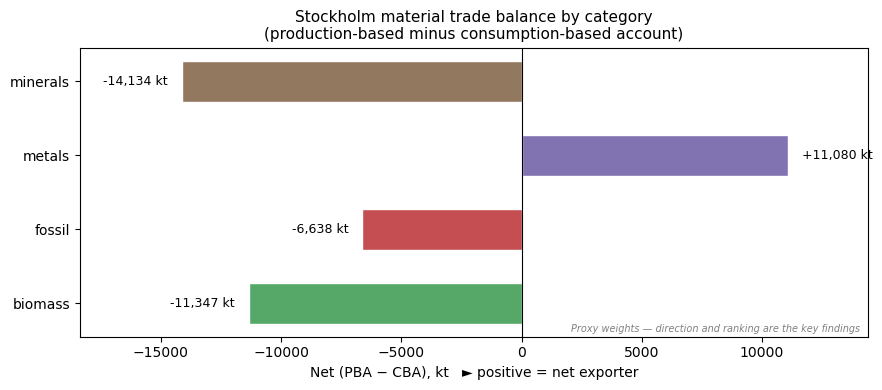

2026-04-14 18:25:57,515 INFO Chart 1 saved


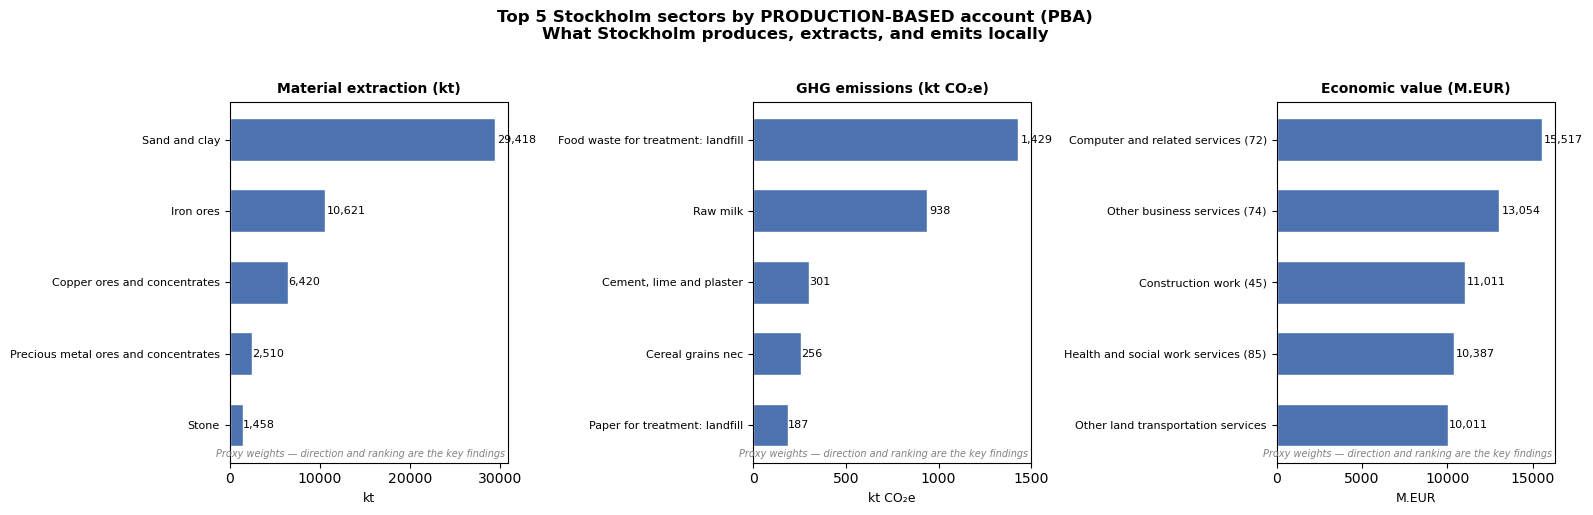

2026-04-14 18:25:58,091 INFO Chart 2 saved


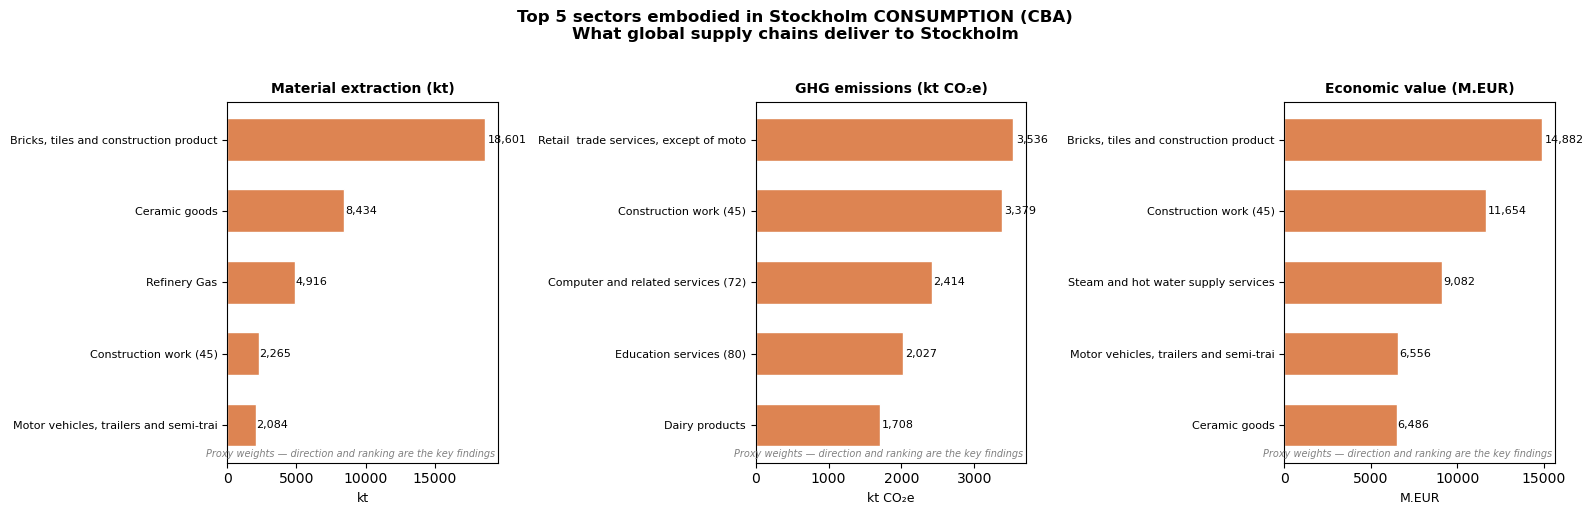

2026-04-14 18:25:58,689 INFO Chart 3 saved
C:\Users\rafaella\AppData\Local\Temp\ipykernel_27936\3444786015.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', max(len(unique_countries), 1))


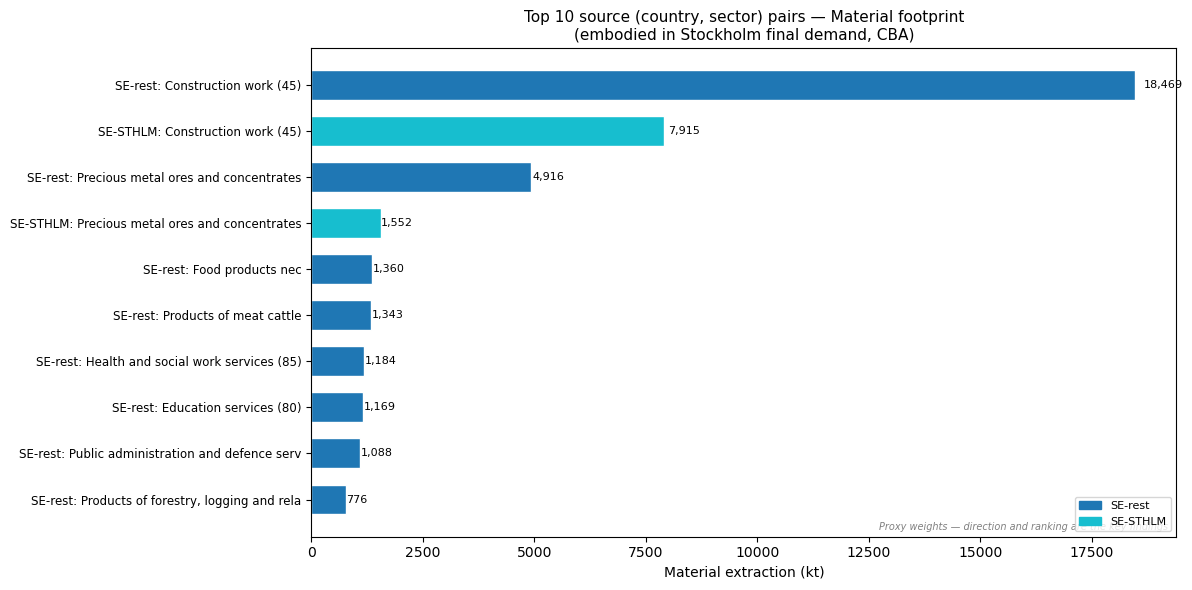

2026-04-14 18:25:59,075 INFO chart4_source_sectors_material.png saved
C:\Users\rafaella\AppData\Local\Temp\ipykernel_27936\3444786015.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap   = plt.cm.get_cmap('tab10', max(len(unique_countries), 1))


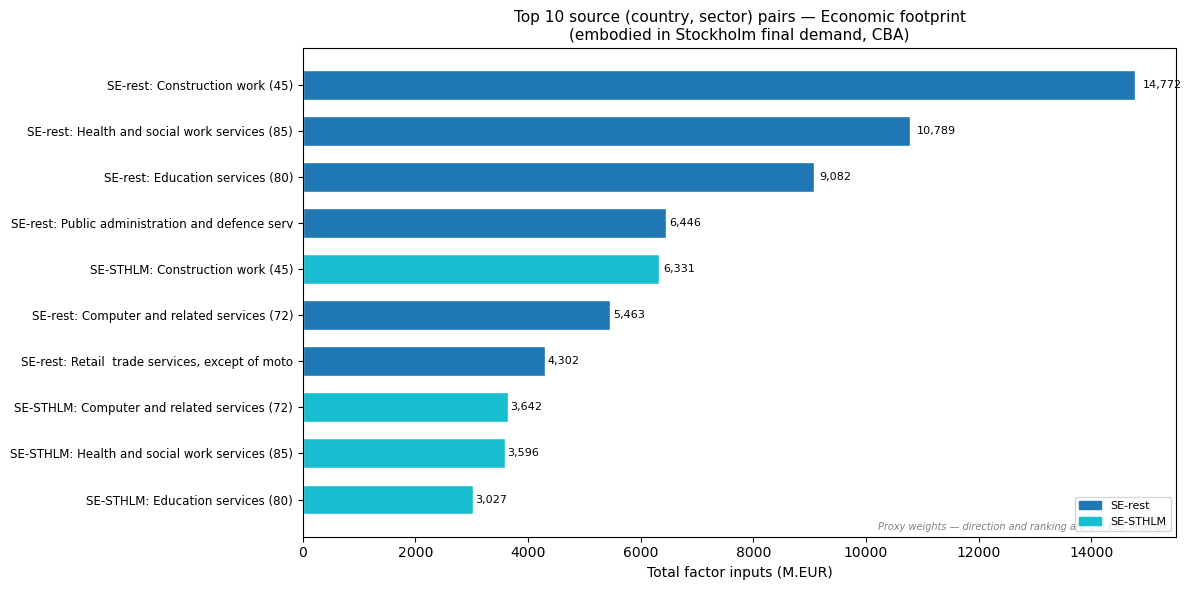

2026-04-14 18:25:59,495 INFO chart6_source_sectors_economic.png saved



All charts saved to: results_stockholm_test


In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

PROXY_NOTE = 'Proxy weights — direction and ranking are the key findings'
C_PBA = "#4C72B0"
C_CBA = "#DD8452"
CAT_COLORS = {
    "biomass":  "#55A868",
    "fossil":   "#C44E52",
    "metals":   "#8172B2",
    "minerals": "#937860",
}

def fmt_country(code):
    if code == REST_OF_SWEDEN_CODE: return 'SE-rest'
    if code == STOCKHOLM_CODE:      return 'SE-STHLM'
    return code

def fmt_pair(idx):
    return f"{fmt_country(idx[0])}: {idx[1][:38]}"

def add_note(ax):
    ax.text(0.99, 0.01, PROXY_NOTE, transform=ax.transAxes,
            fontsize=7, color='grey', ha='right', va='bottom', style='italic')

def country_sector_chart(top_pairs, xlabel, title, filename):
    labels = [fmt_pair(idx) for idx in top_pairs.index]
    vals   = top_pairs.values
    unique_countries = list(dict.fromkeys(idx[0] for idx in top_pairs.index))
    cmap   = plt.cm.get_cmap('tab10', max(len(unique_countries), 1))
    c_map  = {c: cmap(i) for i, c in enumerate(unique_countries)}
    colors = [c_map[idx[0]] for idx in top_pairs.index]
    fig, ax = plt.subplots(figsize=(12, 6))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=colors, edgecolor='white', height=0.65)
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=8.5); ax.invert_yaxis()
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_title(title, fontsize=11)
    patches = [mpatches.Patch(color=c_map[c], label=fmt_country(c))
               for c in unique_countries]
    ax.legend(handles=patches, loc='lower right', fontsize=8)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=8)
    add_note(ax)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f'{filename} saved')


# ── CHART 1: Net material trade balance ─────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
cats  = results['material']['pba_sthlm'].index.tolist()
net   = (results['material']['pba_sthlm'] - results['material']['cba_sthlm']).values
cols  = [CAT_COLORS.get(c, '#999') for c in cats]
bars  = ax.barh(cats, net, color=cols, edgecolor='white', height=0.55)
ax.axvline(0, color='black', linewidth=0.8)
rng = max(abs(net)) * 0.04
for bar, val in zip(bars, net):
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + rng * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f'{val:+,.0f} kt', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Net (PBA − CBA), kt   ► positive = net exporter', fontsize=10)
ax.set_title('Stockholm material trade balance by category\n'
             '(production-based minus consumption-based account)', fontsize=11)
ax.set_xlim(min(net) * 1.3, max(net) * 1.3)
add_note(ax)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart1_material_net_balance.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 1 saved')


# ── CHART 2: Top 5 PBA sectors — three dimensions ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [
    ('Material extraction (kt)',   top['material']['pba_top']),
    ('GHG emissions (kt CO₂e)', top['ghg']['pba_top']),
    ('Economic value (M.EUR)',     top['factor_inputs']['pba_top']),
]
for ax, (title, data) in zip(axes, panels):
    secs = [str(s)[:38] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_PBA, edgecolor='white', height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=8)
    add_note(ax)
fig.suptitle('Top 5 Stockholm sectors by PRODUCTION-BASED account (PBA)\n'
             'What Stockholm produces, extracts, and emits locally',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart2_top_sectors_PBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 2 saved')


# ── CHART 3: Top 5 CBA sectors — three dimensions ───────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
ghg_cba_top = results['ghg'].get('cba_top_sectors',
              pd.Series(dtype=float)).sort_values(ascending=False).head(5)
cba_panels = [
    ('Material extraction (kt)',   top['material']['cba_top']),
    ('GHG emissions (kt CO₂e)', ghg_cba_top),
    ('Economic value (M.EUR)',     top['factor_inputs']['cba_top']),
]
for ax, (title, data) in zip(axes, cba_panels):
    secs = [str(s)[:38] for s in data.index]
    vals = data.values
    y    = np.arange(len(secs))
    ax.barh(y, vals, color=C_CBA, edgecolor='white', height=0.6)
    ax.set_yticks(y); ax.set_yticklabels(secs, fontsize=8); ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(title.split('(')[1].rstrip(')'), fontsize=9)
    for i, v in enumerate(vals):
        ax.text(v * 1.01, i, f'{v:,.0f}', va='center', fontsize=8)
    add_note(ax)
fig.suptitle('Top 5 sectors embodied in Stockholm CONSUMPTION (CBA)\n'
             'What global supply chains deliver to Stockholm',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chart3_top_sectors_CBA.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('Chart 3 saved')


# ── CHARTS 4, 5, 6: Top source (country, sector) pairs ──────────────────
if 'material' in cs:
    country_sector_chart(
        cs['material']['top_pairs'].head(10),
        'Material extraction (kt)',
        'Top 10 source (country, sector) pairs — Material footprint\n'
        '(embodied in Stockholm final demand, CBA)',
        'chart4_source_sectors_material.png')

if 'ghg' in cs:
    country_sector_chart(
        cs['ghg']['top_pairs'].head(10),
        'GHG emissions (kt CO₂e)',
        'Top 10 source (country, sector) pairs — GHG footprint\n'
        '(embodied in Stockholm final demand, CBA)',
        'chart5_source_sectors_ghg.png')

if 'factor_inputs' in cs:
    country_sector_chart(
        cs['factor_inputs']['top_pairs'].head(10),
        'Total factor inputs (M.EUR)',
        'Top 10 source (country, sector) pairs — Economic footprint\n'
        '(embodied in Stockholm final demand, CBA)',
        'chart6_source_sectors_economic.png')

print(f'\nAll charts saved to: {OUTPUT_DIR}')


## Visualize results

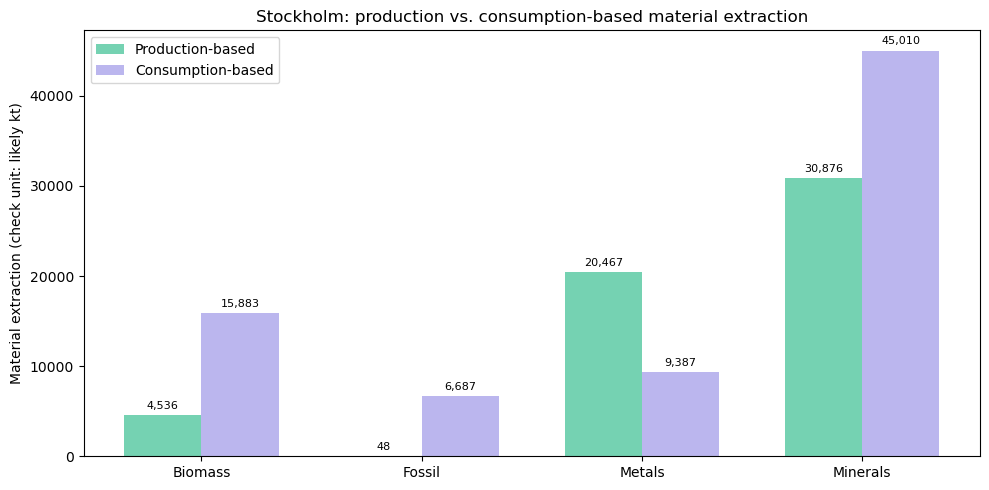

2026-04-14 18:26:24,692 INFO Saved plot: stockholm_material_comparison.png


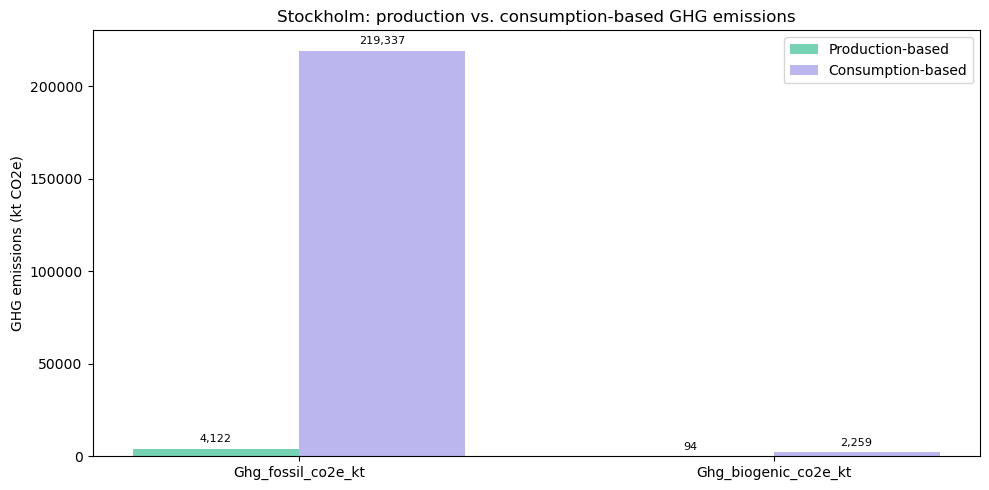

2026-04-14 18:26:25,100 INFO Saved plot: stockholm_ghg_comparison.png


In [21]:
def plot_pba_vs_cba(data, title, ylabel, filename):
    """Side-by-side bar chart comparing PBA and CBA for Stockholm."""
    categories = data['pba_sthlm'].index.tolist()
    pba = data['pba_sthlm'].values
    cba = data['cba_sthlm'].values

    x = np.arange(len(categories))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 5))
    bars1 = ax.bar(x - width/2, pba, width, label='Production-based',
                   color='#5DCAA5', alpha=0.85)
    bars2 = ax.bar(x + width/2, cba, width, label='Consumption-based',
                   color='#AFA9EC', alpha=0.85)

    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in categories])
    ax.legend()

    # Add value labels on bars.
    for bar in bars1:
        h = bar.get_height()
        ax.annotate(f'{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        h = bar.get_height()
        ax.annotate(f'{h:,.0f}', xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=150, bbox_inches='tight')
    plt.show()
    log.info(f"Saved plot: {filename}")


# Plot material comparison.
if 'material' in results:
    plot_pba_vs_cba(
        results['material'],
        "Stockholm: production vs. consumption-based material extraction",
        "Material extraction (check unit: likely kt)",
        "stockholm_material_comparison.png"
    )

# Plot GHG comparison.
if 'ghg' in results:
    plot_pba_vs_cba(
        results['ghg'],
        "Stockholm: production vs. consumption-based GHG emissions",
        "GHG emissions (kt CO2e)",
        "stockholm_ghg_comparison.png"
    )

## Workshop summary

Print a concise overview of key findings for the April 27 presentation.
All values use proxy weights and will be refined in the main study.

In [22]:
print("=" * 70)
print("WORKSHOP SUMMARY: Stockholm preliminary disaggregation results")
print("=" * 70)
print(f"Base year    : {BASE_YEAR}")
print(f"Demand weight: {DEMAND_WEIGHT_STHLM:.0%} (Stockholm share of SE final demand)")
print()

if "material" in results:
    print("─" * 70)
    print("DIMENSION 1 — Material extraction (kt)")
    print("─" * 70)
    print(f"  {'Category':>12}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
    print(f"  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*13}")
    for cat in results["material"]["pba_sthlm"].index:
        pba = results["material"]["pba_sthlm"][cat]
        cba = results["material"]["cba_sthlm"][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"  {cat:>12}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")
    print()

if "ghg" in results:
    print("─" * 70)
    print("DIMENSION 2 — GHG emissions (kt CO2e)")
    print("─" * 70)
    print(f"  {'Category':>22}  {'PBA':>12}  {'CBA':>12}  {'Net':>12}  Direction")
    print(f"  {'-'*22}  {'-'*12}  {'-'*12}  {'-'*12}  {'-'*13}")
    for cat in results["ghg"]["pba_sthlm"].index:
        pba = results["ghg"]["pba_sthlm"][cat]
        cba = results["ghg"]["cba_sthlm"][cat]
        net = pba - cba
        direction = "net exporter" if net > 0 else "NET IMPORTER"
        print(f"  {cat:>22}  {pba:>12,.1f}  {cba:>12,.1f}  {net:>12,.1f}  {direction}")
    print()

if "factor_inputs" in results:
    print("─" * 70)
    print("DIMENSION 3 — Economic value: factor inputs (M.EUR)")
    print("─" * 70)
    pba_total = results["factor_inputs"]["pba_sthlm_total"]
    cba_total = results["factor_inputs"]["cba_sthlm_total"]
    print(f"  PBA (Stockholm production value) : {pba_total:>12,.1f} M.EUR")
    print(f"  CBA (Stockholm consumption value): {cba_total:>12,.1f} M.EUR")
    print(f"  Net (PBA - CBA)                  : {pba_total - cba_total:>12,.1f} M.EUR")
    print()

print("─" * 70)
print("NOTE: These results use PROXY weights, not actual data.")
print("Direction (net importer / net exporter) and ranking are the")
print("key findings. Absolute values will be refined in the main study.")


WORKSHOP SUMMARY: Stockholm preliminary disaggregation results
Base year    : 2024
Demand weight: 28% (Stockholm share of SE final demand)

──────────────────────────────────────────────────────────────────────
DIMENSION 1 — Material extraction (kt)
──────────────────────────────────────────────────────────────────────
      Category           PBA           CBA           Net  Direction
  ------------  ------------  ------------  ------------  -------------
       biomass       4,535.9      15,882.6     -11,346.7  NET IMPORTER
        fossil          48.2       6,686.7      -6,638.5  NET IMPORTER
        metals      20,467.1       9,387.1      11,080.0  net exporter
      minerals      30,876.3      45,009.9     -14,133.6  NET IMPORTER

──────────────────────────────────────────────────────────────────────
DIMENSION 2 — GHG emissions (kt CO2e)
──────────────────────────────────────────────────────────────────────
                Category           PBA           CBA           Net  Direct

## Sanity check: does the split preserve Sweden's totals?

Verify that Stockholm + Rest-of-Sweden PBA sums back to approximately the original Sweden total.

In [23]:
if 'material' in results:
    pba_sthlm = results['material']['pba_sthlm']
    pba_rest = results['material']['pba_rest']
    pba_combined = pba_sthlm + pba_rest

    print("Sanity check: Stockholm PBA + Rest PBA should ~ Sweden total")
    print(f"{'Category':>12s}  {'Stockholm':>12s}  {'Rest of SE':>12s}  {'Combined':>12s}")
    print("-" * 55)
    for cat in pba_sthlm.index:
        print(f"{cat:>12s}  {pba_sthlm[cat]:>12,.1f}  {pba_rest[cat]:>12,.1f}  "
              f"{pba_combined[cat]:>12,.1f}")

Sanity check: Stockholm PBA + Rest PBA should ~ Sweden total
    Category     Stockholm    Rest of SE      Combined
-------------------------------------------------------
     biomass       4,535.9      59,835.7      64,371.6
      fossil          48.2         152.7         200.9
      metals      20,467.1      64,812.5      85,279.5
    minerals      30,876.3      97,796.4     128,672.7
